In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ratings = pd.read_csv('ml-100k/ml-100k/u.data', 
                       sep='\t', 
                       names=['user_id', 'movie_id', 'rating', 'timestamp'])

ratings = ratings.drop('timestamp', axis=1)

print(ratings.shape)
ratings.head()

(100000, 3)


,user_id,movie_id,rating
0,196,242,3
1,186,302,3
2,22,377,1
3,244,51,2
4,166,346,1


In [4]:
import os
os.listdir()

['.ipynb_checkpoints', 'AI(1).ipynb', 'ml-100k']

In [5]:
os.listdir('ml-100k')

['ml-100k']

In [6]:
movies = pd.read_csv('ml-100k/ml-100k/u.item',
                     sep='|',
                     encoding='latin-1',
                     usecols=[0, 1],
                     names=['movie_id', 'movie_title'])

print(movies.shape)
movies.head()

(1682, 2)


,movie_id,movie_title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [7]:
print("Ratings missing values:")
print(ratings.isnull().sum())

print("\nMovies missing values:")
print(movies.isnull().sum())


Ratings missing values:
user_id     0
movie_id    0
rating      0
dtype: int64

Movies missing values:
movie_id       0
movie_title    0
dtype: int64


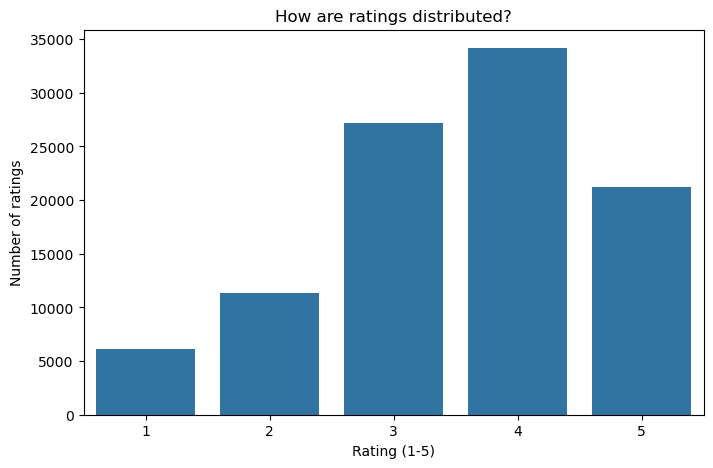

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=ratings)
plt.title('How are ratings distributed?')
plt.xlabel('Rating (1-5)')
plt.ylabel('Number of ratings')
plt.show()

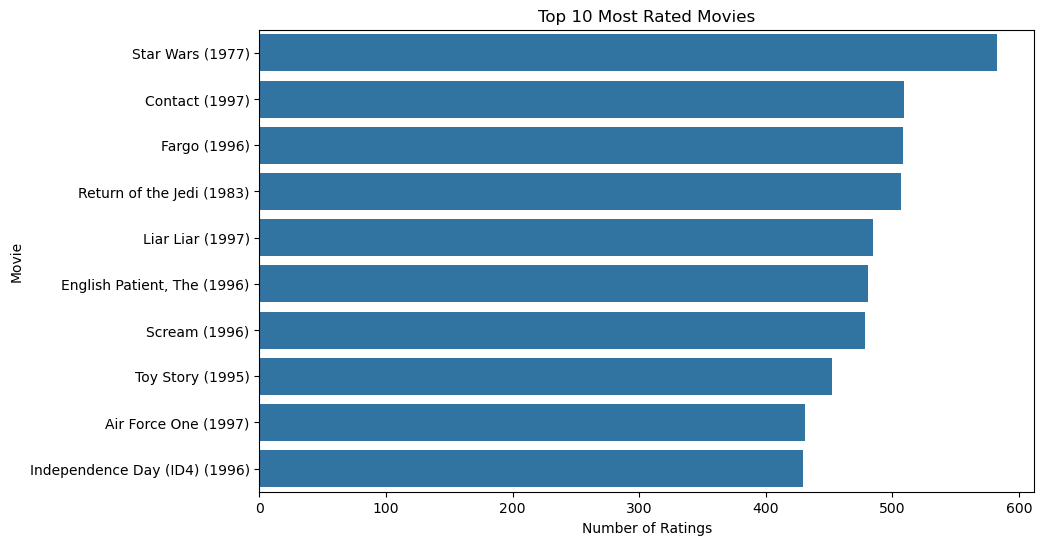

In [9]:
top_movies = ratings.groupby('movie_id')['rating'].count().sort_values(ascending=False).head(10)
top_movies = top_movies.reset_index()
top_movies.columns = ['movie_id', 'rating_count']
top_movies = top_movies.merge(movies, on='movie_id')

plt.figure(figsize=(10, 6))
sns.barplot(x='rating_count', y='movie_title', data=top_movies)
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie')
plt.show()

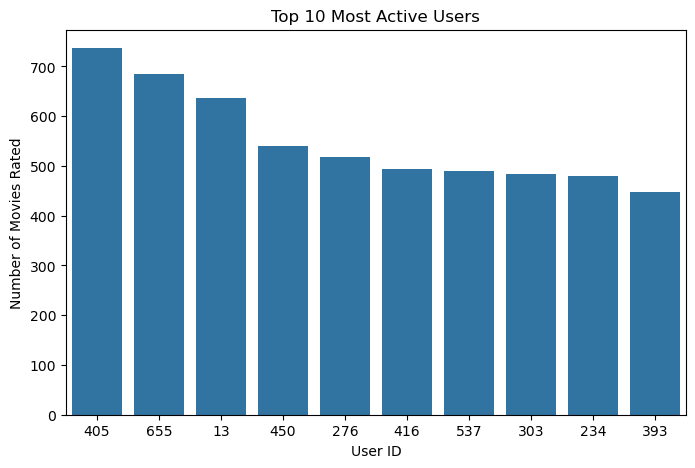

In [10]:
top_users = ratings.groupby('user_id')['rating'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_users.index.astype(str), y=top_users.values)
plt.title('Top 10 Most Active Users')
plt.xlabel('User ID')
plt.ylabel('Number of Movies Rated')
plt.show()

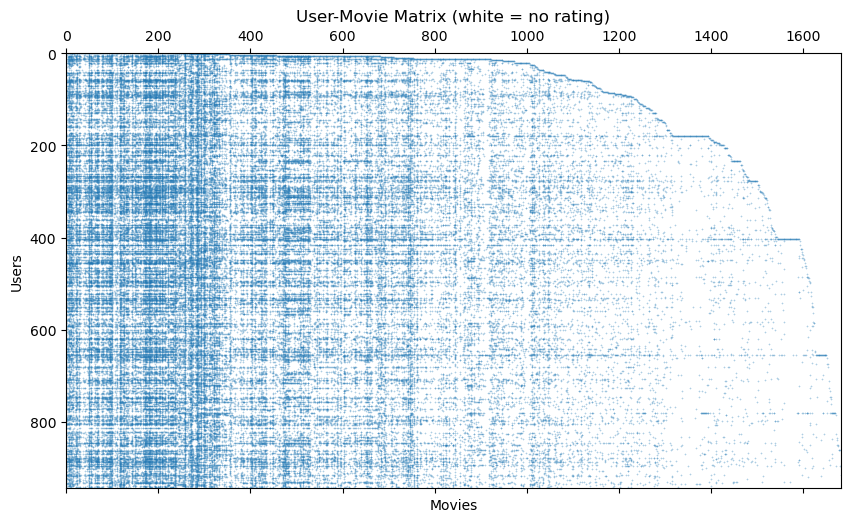

Sparsity: 93.70%


In [11]:
user_movie_matrix = ratings.pivot_table(index='user_id', columns='movie_id', values='rating')

plt.figure(figsize=(10, 6))
plt.spy(user_movie_matrix, markersize=0.1)
plt.title('User-Movie Matrix (white = no rating)')
plt.xlabel('Movies')
plt.ylabel('Users')
plt.show()

total_cells = user_movie_matrix.shape[0] * user_movie_matrix.shape[1]
filled_cells = ratings.shape[0]
sparsity = 1 - (filled_cells / total_cells)
print(f"Sparsity: {sparsity:.2%}")

In [12]:
## Step 1 Complete - Data Loading & EDA

#In this step we loaded the MovieLens 100K dataset which contains 100,000 ratings 
#from users on movies. We checked for missing values (none found) and explored the 
#data visually through charts.
#Most common rating is 4 out of 5
#Star Wars is the most rated movie
#User 405 is the most active user with 700+ ratings
#The data is 93.7% sparse meaning most users have not rated most movies

In [13]:
#Starting Step 2- Content Based Filtering (eg. If you like this movie, here are other movies with similar genre.
#We are not comparing users, just movies.)
#We wanted the system to find movies similar to each other based on their genres.Every movie in the dataset already had a 
#list of 0s and 1s showing which genres it belongs to. For example Toy Story was 1 for Animation, Children's and Comedy and 0 
#for everything else.
#We then used cosine similarity which is basically just a mathematical way of comparing two movies' genre lists 
#and giving a score between 0 and 1. The closer to 1, the more similar the two movies are.
#So when you type in "Toy Story" the function finds Toy Story's genre list, compares it against all 1682 movies  
#sorts them by similarity score, and returns the top 10 most similar ones.


genre_columns = ['unknown', 'Action', 'Adventure', 'Animation', 'Childrens',
                 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
                 'FilmNoir', 'Horror', 'Musical', 'Mystery', 'Romance',
                 'SciFi', 'Thriller', 'War', 'Western']

movies_full = pd.read_csv('ml-100k/ml-100k/u.item',
                          sep='|',
                          encoding='latin-1',
                          names=['movie_id', 'movie_title', 'release_date', 'video_date', 
                                 'imdb_url'] + genre_columns)

movies_full = movies_full[['movie_id', 'movie_title'] + genre_columns]

print(movies_full.shape)
movies_full.head()




(1682, 21)


,movie_id,movie_title,unknown,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,...,Fantasy,FilmNoir,Horror,Musical,Mystery,Romance,SciFi,Thriller,War,Western
0,1,Toy Story (1995),0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [14]:
from sklearn.metrics.pairwise import cosine_similarity

genre_matrix = movies_full[genre_columns].values

cosine_sim = cosine_similarity(genre_matrix)

print(cosine_sim.shape)

(1682, 1682)


In [15]:
def get_content_recommendations(movie_title, num_recommendations=10):
    # find the movie in our list
    if movie_title not in movies_full['movie_title'].values:
        return f"Movie '{movie_title}' not found!"
    
    # get the index of that movie
    idx = movies_full[movies_full['movie_title'] == movie_title].index[0]
    
    # get similarity scores for that movie against all others
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # sort by similarity score, highest first
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # skip the first one (that's the movie itself) and take top N
    sim_scores = sim_scores[1:num_recommendations+1]
    
    # get the movie titles
    movie_indices = [i[0] for i in sim_scores]
    return movies_full['movie_title'].iloc[movie_indices].values

# test it!
recommendations = get_content_recommendations('Toy Story (1995)')
print("Movies similar to Toy Story (1995):\n")
for i, movie in enumerate(recommendations, 1):
    print(f"  {i}. {movie}")

Movies similar to Toy Story (1995):

  1. Aladdin and the King of Thieves (1996)
  2. Aladdin (1992)
  3. Goofy Movie, A (1995)
  4. Santa Clause, The (1994)
  5. Home Alone (1990)
  6. Aristocats, The (1970)
  7. D3: The Mighty Ducks (1996)
  8. Love Bug, The (1969)
  9. Wrong Trousers, The (1993)
  10. Grand Day Out, A (1992)


In [16]:
#Onto Step 3-Collaborative Filtering 
# In step 2 we were comparing movies with other movies. Now we'll be comparing users who have seen movies similar to you
# and then suggest movies that they liked which you haven't seen yet
#So for example if User A and User B both rated Toy Story, Aladdin and Home Alone highly, and User B also loved Jumanji, 
#the system will recommend Jumanji to  User A because someone with very similar taste loved it. 
#No genres involved at all this time. Just pure user behavior patterns.

# create a matrix: rows = users, columns = movies, values = ratings
user_movie_matrix = ratings.pivot_table(index='user_id', 
                                         columns='movie_id', 
                                         values='rating')

print(user_movie_matrix.shape)
user_movie_matrix.head()

(943, 1682)


movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# fill missing ratings with 0
matrix_filled = user_movie_matrix.fillna(0)

# calculate similarity between users
user_similarity = cosine_similarity(matrix_filled)
user_similarity_df = pd.DataFrame(user_similarity, 
                                   index=user_movie_matrix.index, 
                                   columns=user_movie_matrix.index)

print(user_similarity_df.shape)

(943, 943)


In [18]:
def get_cf_recommendations(user_id, num_recommendations=10):
    # check if user exists
    if user_id not in user_movie_matrix.index:
        return f"User {user_id} not found!"
    
    # get the most similar users to this user
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:51]
    
    # get movies this user has already watched
    watched_movies = user_movie_matrix.loc[user_id].dropna().index.tolist()
    
    # collect movie scores from similar users
    recommendations = {}
    for similar_user, similarity_score in similar_users.items():
        # get movies the similar user rated highly (4 or 5)
        similar_user_movies = user_movie_matrix.loc[similar_user].dropna()
        similar_user_movies = similar_user_movies[similar_user_movies >= 4]
        
        for movie_id, rating in similar_user_movies.items():
            if movie_id not in watched_movies:
                if movie_id not in recommendations:
                    recommendations[movie_id] = 0
                recommendations[movie_id] += similarity_score * rating
    
    # sort by score and take top N
    recommendations = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)
    top_movie_ids = [movie_id for movie_id, score in recommendations[:num_recommendations]]
    
    # return movie titles
    result = movies[movies['movie_id'].isin(top_movie_ids)]['movie_title'].values
    return result

# test it!
recs = get_cf_recommendations(1)
print("Recommendations for User 1:\n")
for i, movie in enumerate(recs, 1):
    print(f"  {i}. {movie}")
    


Recommendations for User 1:

  1. Schindler's List (1993)
  2. One Flew Over the Cuckoo's Nest (1975)
  3. E.T. the Extra-Terrestrial (1982)
  4. Heathers (1989)
  5. Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)
  6. Trainspotting (1996)
  7. Casablanca (1942)
  8. Gandhi (1982)
  9. Glory (1989)
  10. Stand by Me (1986)


In [19]:
#Step 4 - Hybrid Recommendation System
#In this step we combine both previous approaches into one. Content based filtering found movies with similar genres, 
#and collaborative filtering found movies liked by similar users. Neither approach alone is perfect so we merge them 
#using a weighted formula, giving 60% importance to collaborative filtering and 40% to content based filtering. 
#The result is a more accurate and well rounded recommendation.

def get_hybrid_recommendations(user_id, movie_title, num_recommendations=10):
    
    # get content based scores
    if movie_title not in movies_full['movie_title'].values:
        return f"Movie '{movie_title}' not found!"
    
    idx = movies_full[movies_full['movie_title'] == movie_title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:]
    
    content_scores = {}
    for i, score in sim_scores:
        movie_id = movies_full.iloc[i]['movie_id']
        content_scores[movie_id] = score
    
    # get collaborative filtering scores
    if user_id not in user_movie_matrix.index:
        return f"User {user_id} not found!"
    
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:11]
    watched_movies = user_movie_matrix.loc[user_id].dropna().index.tolist()
    
    cf_scores = {}
    for similar_user, similarity_score in similar_users.items():
        similar_user_movies = user_movie_matrix.loc[similar_user].dropna()
        similar_user_movies = similar_user_movies[similar_user_movies >= 4]
        for mid, rating in similar_user_movies.items():
            if mid not in watched_movies:
                if mid not in cf_scores:
                    cf_scores[mid] = 0
                cf_scores[mid] += similarity_score * rating
    
    # normalize both scores between 0 and 1
    max_cf = max(cf_scores.values()) if cf_scores else 1
    max_cb = max(content_scores.values()) if content_scores else 1
    
    # combine scores using hybrid formula
    hybrid_scores = {}
    all_movies = set(content_scores.keys()) | set(cf_scores.keys())
    
    for mid in all_movies:
        if mid not in watched_movies:
            cb = content_scores.get(mid, 0) / max_cb
            cf = cf_scores.get(mid, 0) / max_cf
            hybrid_scores[mid] = 0.6 * cf + 0.4 * cb
    
    # sort and get top N
    top_movies = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)[:num_recommendations]
    top_ids = [mid for mid, score in top_movies]
    
    result = movies[movies['movie_id'].isin(top_ids)]['movie_title'].values
    return result

# test it!
recs = get_hybrid_recommendations(1, 'Toy Story (1995)')
print("Hybrid Recommendations for User 1 based on Toy Story:\n")
for i, movie in enumerate(recs, 1):
    print(f"  {i}. {movie}")

Hybrid Recommendations for User 1 based on Toy Story:

  1. Schindler's List (1993)
  2. One Flew Over the Cuckoo's Nest (1975)
  3. Pinocchio (1940)
  4. Close Shave, A (1995)
  5. Kingpin (1996)
  6. Bob Roberts (1992)
  7. Harold and Maude (1971)
  8. Heathers (1989)
  9. Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)
  10. Beauty and the Beast (1991)


In [20]:
#Step 5 - Evaluation
#In this step we measure how accurate our recommendation system is. We do this by hiding some ratings from the system, 
#letting it predict what those ratings would be, and then comparing the predictions to the real values. 
#We use two metrics, RMSE and MAE, both of which measure how far off our predictions are from the actual ratings. 
#The lower the score the better.

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# pick users who have rated at least 20 movies
active_users = ratings.groupby('user_id')['rating'].count()
active_users = active_users[active_users >= 20].index.tolist()

actual = []
predicted = []

for user_id in active_users[:50]:  # test on first 50 active users
    # get movies this user rated
    user_ratings = ratings[ratings['user_id'] == user_id]
    
    for _, row in user_ratings.iterrows():
        movie_id = row['movie_id']
        actual_rating = row['rating']
        
        # predict rating using similar users
        similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:11]
        
        numerator = 0
        denominator = 0
        
        for similar_user, similarity in similar_users.items():
            if movie_id in user_movie_matrix.columns:
                rating = user_movie_matrix.loc[similar_user, movie_id]
                if not np.isnan(rating):
                    numerator += similarity * rating
                    denominator += abs(similarity)
        
        if denominator > 0:
            predicted_rating = numerator / denominator
            actual.append(actual_rating)
            predicted.append(predicted_rating)

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

RMSE: 1.0908
MAE:  0.8518


In [21]:
import scipy
print(scipy.__version__)

1.16.3


In [22]:
#SVD (Singular Value Decomposition)
#SVD is a mathematical technique that analyses the user-movie rating matrix and finds hidden patterns.
#For example that users who like Action also tend to like Thriller. 
#It uses these patterns to fill in missing ratings and predict what a user would rate a movie they haven't seen yet.
#It is a more advanced form of collaborative filtering.

from scipy.sparse.linalg import svds

# fill NaN with 0
matrix_filled = user_movie_matrix.fillna(0).values

# apply SVD - k=50 means we find 50 hidden patterns
U, sigma, Vt = svds(matrix_filled, k=50)

# convert sigma to a diagonal matrix
sigma = np.diag(sigma)

# reconstruct the full predicted ratings matrix
predicted_ratings = np.dot(np.dot(U, sigma), Vt)
predicted_ratings_df = pd.DataFrame(predicted_ratings, 
                                     index=user_movie_matrix.index,
                                     columns=user_movie_matrix.columns)

print("SVD matrix shape:", predicted_ratings_df.shape)
print("\nSample predicted ratings for User 1:")
print(predicted_ratings_df.loc[1].head(10).round(2))

SVD matrix shape: (943, 1682)

Sample predicted ratings for User 1:
movie_id
1     6.45
2     2.95
3     1.63
4     3.05
5     1.65
6     1.68
7     3.67
8     0.23
9     1.58
10    3.36
Name: 1, dtype: float64


In [23]:
def get_svd_recommendations(user_id, num_recommendations=10):
    # get movies this user has already watched
    watched_movies = user_movie_matrix.loc[user_id].dropna().index.tolist()
    
    # get SVD predicted ratings for this user
    user_predictions = predicted_ratings_df.loc[user_id].copy()
    
    # remove movies they already watched
    user_predictions = user_predictions.drop(watched_movies)
    
    # sort by predicted rating and take top N
    top_movies = user_predictions.sort_values(ascending=False).head(num_recommendations)
    top_ids = top_movies.index.tolist()
    
    result = movies[movies['movie_id'].isin(top_ids)]['movie_title'].values
    return result

# test it!
recs = get_svd_recommendations(1)
print("SVD Recommendations for User 1:\n")
for i, movie in enumerate(recs, 1):
    print(f"  {i}. {movie}")

SVD Recommendations for User 1:

  1. Ulee's Gold (1997)
  2. One Flew Over the Cuckoo's Nest (1975)
  3. Clueless (1995)
  4. True Lies (1994)
  5. Batman (1989)
  6. E.T. the Extra-Terrestrial (1982)
  7. Tombstone (1993)
  8. Die Hard: With a Vengeance (1995)
  9. Piano, The (1993)
  10. Dave (1993)


In [24]:
def precision_recall_at_k(user_id, k=10, threshold=4):
    # get all ratings for this user
    user_ratings = user_movie_matrix.loc[user_id].dropna()
    
    if len(user_ratings) < 20:
        return None, None
    
    # split into train (80%) and test (20%)
    test_movies = user_ratings.sample(frac=0.2, random_state=42)
    
    # movies the user actually liked in the test set
    actual_liked = test_movies[test_movies >= threshold].index.tolist()
    
    if len(actual_liked) == 0:
        return None, None
    
    # get SVD top K recommendations excluding training movies
    train_movies = user_ratings.drop(test_movies.index).index.tolist()
    user_preds = predicted_ratings_df.loc[user_id].drop(train_movies)
    top_k = user_preds.sort_values(ascending=False).head(k).index.tolist()
    
    # how many recommended movies are in the liked test set
    hits = len(set(top_k) & set(actual_liked))
    
    precision = hits / k
    recall = hits / len(actual_liked)
    
    return precision, recall

# test on multiple users and average
precisions, recalls = [], []

for user_id in user_movie_matrix.index[:100]:
    p, r = precision_recall_at_k(user_id, k=10)
    if p is not None:
        precisions.append(p)
        recalls.append(r)

print(f"Precision@10: {np.mean(precisions):.4f}")
print(f"Recall@10:    {np.mean(recalls):.4f}")

Precision@10: 0.5040
Recall@10:    0.4901


In [25]:
#Item Based Collaborative Filtering
#Instead of finding similar users, item based collaborative filtering finds similar movies based on how they were rated
#across all users. If Movie A and Movie B tend to get similar ratings from the same users, they are considered similar. 
#This is different from content based filtering which compared genres, here similarity is based purely on rating patterns.

# calculate similarity between movies based on ratings
movie_similarity = cosine_similarity(matrix_filled.T)
movie_similarity_df = pd.DataFrame(movie_similarity,
                                    index=user_movie_matrix.columns,
                                    columns=user_movie_matrix.columns)

print(movie_similarity_df.shape)

(1682, 1682)


In [26]:
def get_item_cf_recommendations(user_id, num_recommendations=10):
    # check if user exists
    if user_id not in user_movie_matrix.index:
        return f"User {user_id} not found!"
    
    # get movies this user has already rated
    watched_movies = user_movie_matrix.loc[user_id].dropna()
    
    # for each watched movie, find similar movies
    recommendations = {}
    for movie_id, rating in watched_movies.items():
        # get similar movies to this one
        similar_movies = movie_similarity_df[movie_id].sort_values(ascending=False)[1:6]
        
        for similar_movie_id, similarity in similar_movies.items():
            # skip movies user already watched
            if similar_movie_id not in watched_movies.index:
                if similar_movie_id not in recommendations:
                    recommendations[similar_movie_id] = 0
                # weight by both similarity and how much user liked the movie
                recommendations[similar_movie_id] += similarity * rating
    
    # sort and get top N
    top_movies = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)[:num_recommendations]
    top_ids = [mid for mid, score in top_movies]
    
    result = movies[movies['movie_id'].isin(top_ids)]['movie_title'].values
    return result

# test it!
recs = get_item_cf_recommendations(1)
print("Item Based CF Recommendations for User 1:\n")
for i, movie in enumerate(recs, 1):
    print(f"  {i}. {movie}")

Item Based CF Recommendations for User 1:

  1. Secrets & Lies (1996)
  2. True Lies (1994)
  3. Mrs. Doubtfire (1993)
  4. Batman (1989)
  5. Mission: Impossible (1996)
  6. E.T. the Extra-Terrestrial (1982)
  7. Like Water For Chocolate (Como agua para chocolate) (1992)
  8. Die Hard: With a Vengeance (1995)
  9. Speed (1994)
  10. Beauty and the Beast (1991)


K=5: RMSE = 1.1401
K=10: RMSE = 1.0791
K=20: RMSE = 1.0460
K=30: RMSE = 1.0349
K=50: RMSE = 1.0305


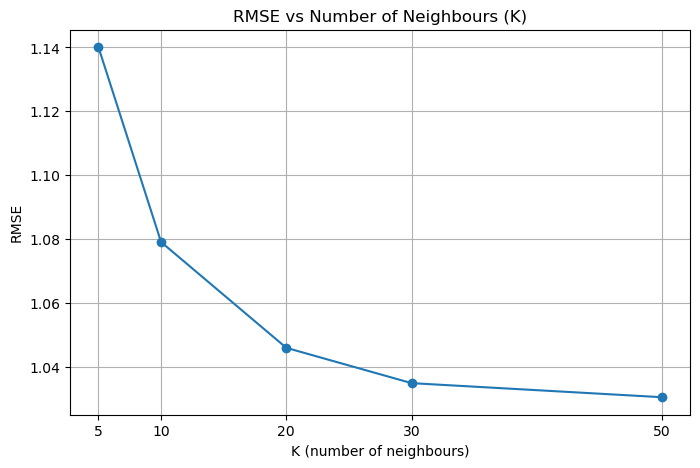


Best K: 50 with RMSE: 1.0305


In [27]:
#Hyperparameter Tuning
#In collaborative filtering, K refers to how many similar users or movies we consider when making recommendations. 
#Too few neighbours means we don't have enough information, too many means we include users who aren't actually that similar.
#We test different values of K and pick the one that gives the lowest RMSE score.

from sklearn.metrics import mean_squared_error

k_values = [5, 10, 20, 30, 50]
rmse_scores = []

for k in k_values:
    actual = []
    predicted = []
    
    for user_id in user_movie_matrix.index[:30]:
        user_ratings = ratings[ratings['user_id'] == user_id]
        
        similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:k+1]
        
        for _, row in user_ratings.iterrows():
            movie_id = row['movie_id']
            actual_rating = row['rating']
            
            numerator = 0
            denominator = 0
            
            for similar_user, similarity in similar_users.items():
                rating = user_movie_matrix.loc[similar_user, movie_id]
                if not np.isnan(rating):
                    numerator += similarity * rating
                    denominator += abs(similarity)
            
            if denominator > 0:
                predicted_rating = numerator / denominator
                actual.append(actual_rating)
                predicted.append(predicted_rating)
    
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    rmse_scores.append(rmse)
    print(f"K={k}: RMSE = {rmse:.4f}")

# plot it
plt.figure(figsize=(8, 5))
plt.plot(k_values, rmse_scores, marker='o')
plt.title('RMSE vs Number of Neighbours (K)')
plt.xlabel('K (number of neighbours)')
plt.ylabel('RMSE')
plt.xticks(k_values)
plt.grid(True)
plt.show()

best_k = k_values[rmse_scores.index(min(rmse_scores))]
print(f"\nBest K: {best_k} with RMSE: {min(rmse_scores):.4f}")

In [28]:
import pickle

# save everything we need
pickle.dump(cosine_sim, open('cosine_sim.pkl', 'wb'))
pickle.dump(user_similarity_df, open('user_similarity_df.pkl', 'wb'))
pickle.dump(movie_similarity_df, open('movie_similarity_df.pkl', 'wb'))
pickle.dump(predicted_ratings_df, open('predicted_ratings_df.pkl', 'wb'))
pickle.dump(movies_full, open('movies_full.pkl', 'wb'))
pickle.dump(movies, open('movies.pkl', 'wb'))
pickle.dump(user_movie_matrix, open('user_movie_matrix.pkl', 'wb'))

print("All models saved!")

All models saved!


In [1]:
import requests

TMDB_API_KEY = "003b359044adc636b66d5c783244390d"  

title = "Toy Story"
url = f"https://api.themoviedb.org/3/search/movie?api_key={TMDB_API_KEY}&query={title}"
response = requests.get(url)
print(response.json())

{'page': 1, 'results': [{'adult': False, 'backdrop_path': '/3Rfvhy1Nl6sSGJwyjb0QiZzZYlB.jpg', 'genre_ids': [10751, 35, 16, 12], 'id': 862, 'original_language': 'en', 'original_title': 'Toy Story', 'overview': "Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.", 'popularity': 21.1087, 'poster_path': '/uXDfjJbdP4ijW5hWSBrPrlKpxab.jpg', 'release_date': '1995-11-22', 'title': 'Toy Story', 'video': False, 'vote_average': 7.971, 'vote_count': 19737}, {'adult': False, 'backdrop_path': '/uAfhsySkr1UzQg1zdg3dZQRz9Fd.jpg', 'genre_ids': [16, 10751, 35], 'id': 10193, 'original_language': 'en', 'original_title': 'Toy Story 3', 'overview': "Woody, Buzz, and the rest of Andy's toys haven't been played with in years. With Andy about to go to college, t